# Procesamiento de señales aplicado en el terremoto de Maule

Ocurrido el 27 de febrero de 2010 frente a la costa de la región del Maule (Chile).

Un sismograma es una serie temporal: amplitud (movimiento del suelo, en nuestro caso "cuentas" es decir el valor crudo del sensor) en función del tiempo. Pero no es una señal cualquiera — tiene una estructura particular porque el terremoto no llega "todo junto". Un mismo evento genera distintos tipos de ondas que viajan a distinta velocidad y se van registrando en secuencia:

- Ondas P: las más rápidas, llegan primero, alta frecuencia relativamente.
- Ondas S: llegan después, algo más lentas, frecuencia intermedia.
- Ondas superficiales: llegan al final, viajan más lento, pero suelen tener mayor amplitud y frecuencias más bajas.

Esto es justo lo que hace que la señal sea no estacionaria: el contenido de frecuencias de la señal cambia con el tiempo. Al principio del registro predominan ciertas frecuencias, después otras. Una señal estacionaria (como un tono puro constante) tendría siempre el mismo contenido espectral a lo largo del tiempo; un sismograma no.

Como primer instancia de nuestro trabajajo tenemos un análisis exploratorio básico, donde miramos si hay faltantes y distristribución de los datos. Posteriormente aplicamos filtros para eliminar los ruidos de baja y alta frecuencia, con el objetivo de quedarnos con la señal sísmica de interés: ondas P, S y superficiales, que suelen concentrarse aproximadamente entre 0.05 y 10 Hz (para un sismo grande y regional/teleseísmico como este). 

In [24]:
!pip install obspy
!pip install pandas
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import pandas as pd
import matplotlib.pyplot as plt

event_client = Client("USGS")
waveform_client = Client("IRIS")

# Para los filtros 
from scipy.signal import butter, filtfilt
from scipy.signal import firwin, filtfilt


/home/ldvr/miniconda3/lib/python3.13/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


### Busqueda del evento en el catálogo de obspy

Se filtra por rango de fechas, magnitud y ubicación aproximada (frente a la costa centro-sur de Chile).

In [5]:
t0 = UTCDateTime("2010-02-27T00:00:00")
t1 = UTCDateTime("2010-02-27T12:00:00")

catalog = event_client.get_events(
    starttime=t0,
    endtime=t1,
    minmagnitude=8.0, #tener en cuenta que fue de 8.2
    maxmagnitude=9.0,
    minlatitude=-40,
    maxlatitude=-30,
    minlongitude=-75,
    maxlongitude=-70,
)

print(catalog)
event = catalog[0]
print(event)

1 Event(s) in Catalog:
2010-02-27T06:34:11.530000Z | -36.122,  -72.898 | 8.8  mww | manual
Event:	2010-02-27T06:34:11.530000Z | -36.122,  -72.898 | 8.8  mww | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=official20100227063411530_30&format=quakeml")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='official', creation_time=UTCDateTime(2026, 7, 12, 19, 28, 40, 54000))
	    preferred_origin_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/official20100227063411530_30/official/1478119680198")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/official20100227063411530_30/official/1478119680198#magnitude")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [6]:
origen = event.preferred_origin() or event.origens[0]
magnitud = event.preferred_magnitude() or event.magnituds[0]

origen = origen
print(f"Hora origen: {origen.time}")
print(f"Latitud:     {origen.latitude}")
print(f"Longitud:    {origen.longitude}")
print(f"Profundidad: {origen.depth / 1000:.1f} km")
print(f"Magnitud:    {magnitud.mag} {magnitud.magnitude_type}")

Hora origen: 2010-02-27T06:34:11.530000Z
Latitud:     -36.122
Longitud:    -72.898
Profundidad: 22.9 km
Magnitud:    8.8 mww


<Mark>Por qué decis 8.2? Según los prints que yo veo es 8.8 mww. <Mark>

#### descarga de la forma de onda

Se elige arbitrariamente IU.LVC (Limón Verde, Chile), canal BHZ vertical, banda ancha, y una ventana de 1 minuto antes y 30 minutos después del origen del sismo.

el resultado es una traza sismica, objeto de obspy bajo el cual se puede plotear y hacer varias cosas más. 

In [7]:
network = "IU"
station = "LVC"
location = "00"
channel = "BHZ"

st = waveform_client.get_waveforms(
    network=network,
    station=station,
    location=location,
    channel=channel,
    starttime=origen.time - 60,
    endtime=origen.time + 1800,
)

print(st)


1 Trace(s) in Stream:
IU.LVC.00.BHZ | 2010-02-27T06:33:11.569538Z - 2010-02-27T07:04:11.519538Z | 20.0 Hz, 37200 samples


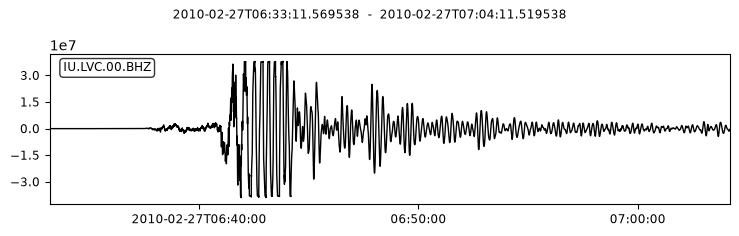

In [8]:
st.plot();

In [9]:

traza = st[0]
df = pd.DataFrame({"tiempo_s": traza.times(), "amplitud": traza.data})
df.head()

,tiempo_s,amplitud
0,0.00,2028
1,0.05,1973
2,0.10,1931
3,0.15,1894
4,0.20,1825


In [10]:
#tipos de dato y cantidad de registros por columna
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 37200 entries, 0 to 37199
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tiempo_s  37200 non-null  float64
 1   amplitud  37200 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 436.1 KB


In [11]:
df.describe()

,tiempo_s,amplitud
count,37200.000000,3.720000e+04
mean,929.975000,1.487626e+04
std,536.942967,9.661958e+06
min,0.000000,-3.893963e+07
25%,464.987500,-1.617710e+06
50%,929.975000,2.023000e+03
75%,1394.962500,1.777808e+06
max,1859.950000,3.796414e+07


In [12]:
#cantidad de valores nulos por columna
df.isnull().sum()

tiempo_s    0
amplitud    0
dtype: int64

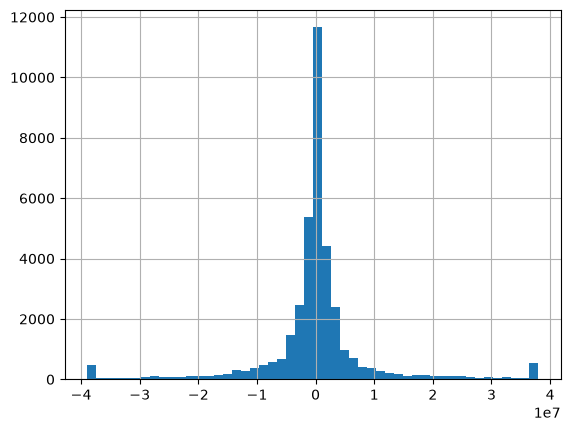

In [13]:
#distribucion de la columna amplitud
df["amplitud"].hist(bins=50);

In [14]:
#valores minimos y maximo de la columna amplitud
print(df["amplitud"].min(), df["amplitud"].max())

-38939634 37964140


### Calculo del momento sísmico $(Mo)$

Siguiendo la fórmula detallada en la sección 3.2.1 del paper, 

$$
M_0 = \frac{4\pi\rho v^3}{2\psi_0}\,R\,\Omega_0 
$$

**Donde:**

- $M_0$ = Momento sísmico.
- $\Omega_0$ = Nivel plano del espectro, calculado a partir del espectro de amplitudes.
- $\rho$ = Densidad de la corteza terrestre, es decir el medio en el cual ocurre el sismo. Es $2.8 \ \text{gr/cm}^3$.
- $R$ = Distancia epicentral.
- $v$ = Velocidad de la onda P, aparentemente el estandar suele ser contarlo como $5 \ \text{km/seg}$. Chequear
- $\psi_0$ = Patrón de radiación, asumido como $0.4$ basado en el paper de Brune citado en el trabajo (Brune, 1970).

## Filtrado digital de la señal (FIR e IIR)

Trabajamos sobre la señal cruda en cuentas del digitalizador (sin remover respuesta instrumental), ya que no afecta el análisis de filtrado/frecuencia. <Mark>ver si el paper lo lleva a unidades de medida independientes del sensor <Mark>

Elegimos un filtro **pasabanda 0.1 - 10 Hz**, que es el rango donde suele concentrarse la energía de un sismograma de banda ancha (por debajo de 0.1 Hz hay deriva/ruido de muy baja frecuencia; por encima de 10 Hz suele haber ruido de alta frecuencia poco relevante para este análisis).

Vamos a aplicar el mismo pasabanda con dos enfoques distintos (IIR y FIR) para poder compararlos más adelante.


In [21]:

fs = traza.stats.sampling_rate  # frecuencia de muestreo de la traza, en Hz
lowcut = 0.1   # Hz
highcut = 9.0 # Hz
order = 4      # orden del filtro IIR

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    # filtfilt aplica el filtro hacia adelante y hacia atras -> fase cero (no desfasa la señal)
    y = filtfilt(b, a, data)
    return y

df["amplitud_iir"] = butter_bandpass_filter(df["amplitud"].values, lowcut, highcut, fs, order)
df[["amplitud", "amplitud_iir"]].head()


,amplitud,amplitud_iir
0,2028,-215.155251
1,1973,-258.703394
2,1931,-289.971067
3,1894,-315.393419
4,1825,-374.312853


In [25]:
print(df["amplitud"].mean())       # va a dar un numero bien alejado de 0 (el "offset")
print(df["amplitud_iir"].mean())   # deberia dar mucho mas cerca de 0

14876.25940860215
-91.37998154236294


Podemos decir que el filtro cumplio su objetivo, la señal parece estar más centrada luego de eliminar las frecuencias por encima de 9 y por debajo de 1. 

### Veamos en que influye el parametro order en el filtro IIR    
Es el que define que tan abrupto es el pasaje:    
order=1 (transición bien suave, va a filtrar poco) vs order=8 (transición bien marcada) 

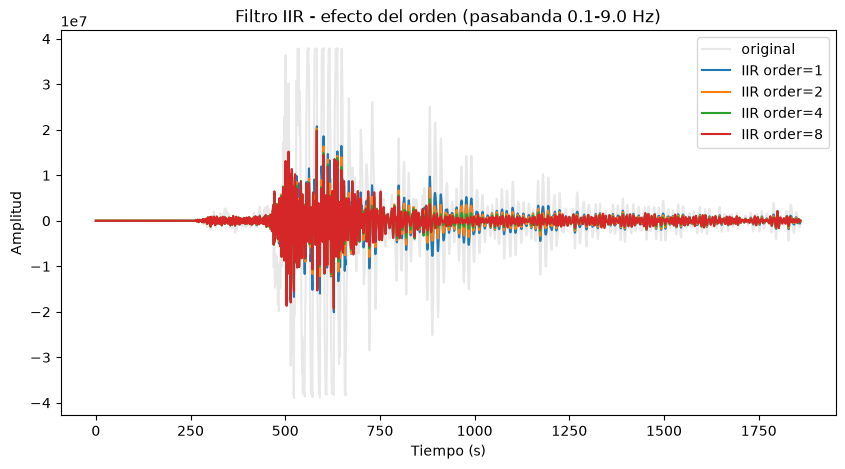

In [30]:
orders_to_test = [1, 2, 4, 8]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["tiempo_s"], df["amplitud"], color="lightgray", label="original", alpha=0.5)

for o in orders_to_test:
    y = butter_bandpass_filter(df["amplitud"].values, lowcut, highcut, fs, order=o)
    ax.plot(df["tiempo_s"], y, label=f"IIR order={o}")

ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_title(f"Filtro IIR - efecto del orden (pasabanda {lowcut}-{highcut} Hz)")
ax.legend()
plt.show()

Efectivamente podemos ver que al aumentar el valor del order pasan menos frecuencias cercanas a los limites del pasabanda. 

In [27]:
numtaps = 401  # cantidad de coeficientes del filtro FIR (impar, entre mas alto, mas "abrupto" el corte pero mas costoso)

fir_coef = firwin(numtaps, [lowcut, highcut], pass_zero=False, fs=fs)

df["amplitud_fir"] = filtfilt(fir_coef, [1.0], df["amplitud"].values)
df[["amplitud", "amplitud_iir", "amplitud_fir"]].head()


,amplitud,amplitud_iir,amplitud_fir
0,2028,-215.155251,0.031378
1,1973,-258.703394,-52.127555
2,1931,-289.971067,-91.792789
3,1894,-315.393419,-125.526063
4,1825,-374.312853,-192.598172


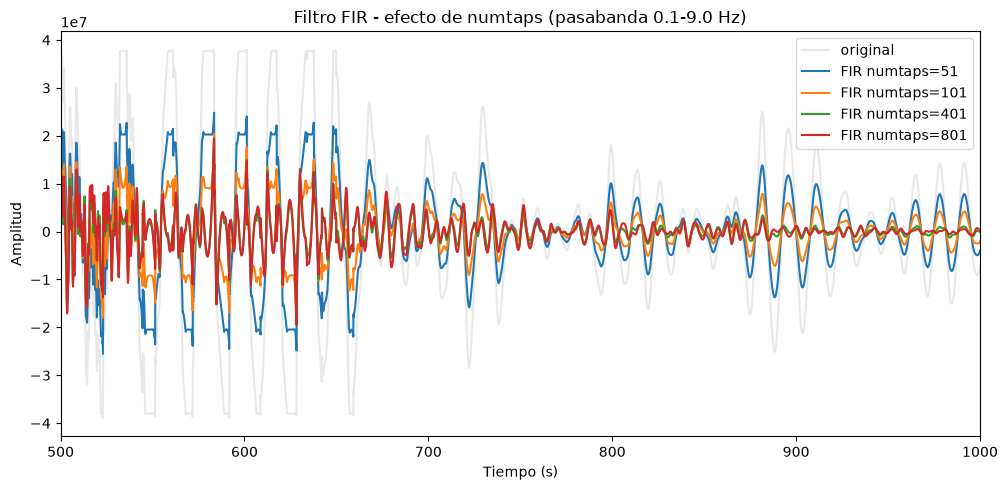

In [ ]:
numtaps_to_test = [51, 101, 401, 801]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["tiempo_s"], df["amplitud"], color="lightgray", label="original", alpha=0.5)

for nt in numtaps_to_test:
    coef = firwin(nt, [lowcut, highcut], pass_zero=False, fs=fs)
    y = filtfilt(coef, [1.0], df["amplitud"].values)
    ax.plot(df["tiempo_s"], y, label=f"FIR numtaps={nt}")

ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_title(f"Filtro FIR - efecto de numtaps (pasabanda {lowcut}-{highcut} Hz)")
ax.legend()
plt.tight_layout()
ax.set_xlim(500, 1000)  # zoom, defini los valores en base al grafico de abajo. 
plt.show() # si comentamos la linea de arriba se ve la serie completa

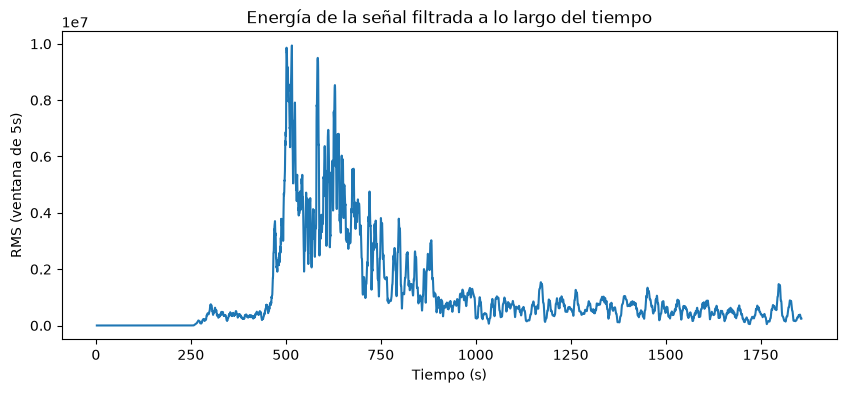

In [ ]:
window_size = int(5 * fs)  # ventana de 5 segundos

rms = df["amplitud_iir"].rolling(window=window_size, center=True).apply(
    lambda x: np.sqrt(np.mean(x**2))
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["tiempo_s"], rms)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("RMS (ventana de 5s)")
ax.set_title("Energía de la señal filtrada a lo largo del tiempo")
plt.show()

### Comparación de los filtros

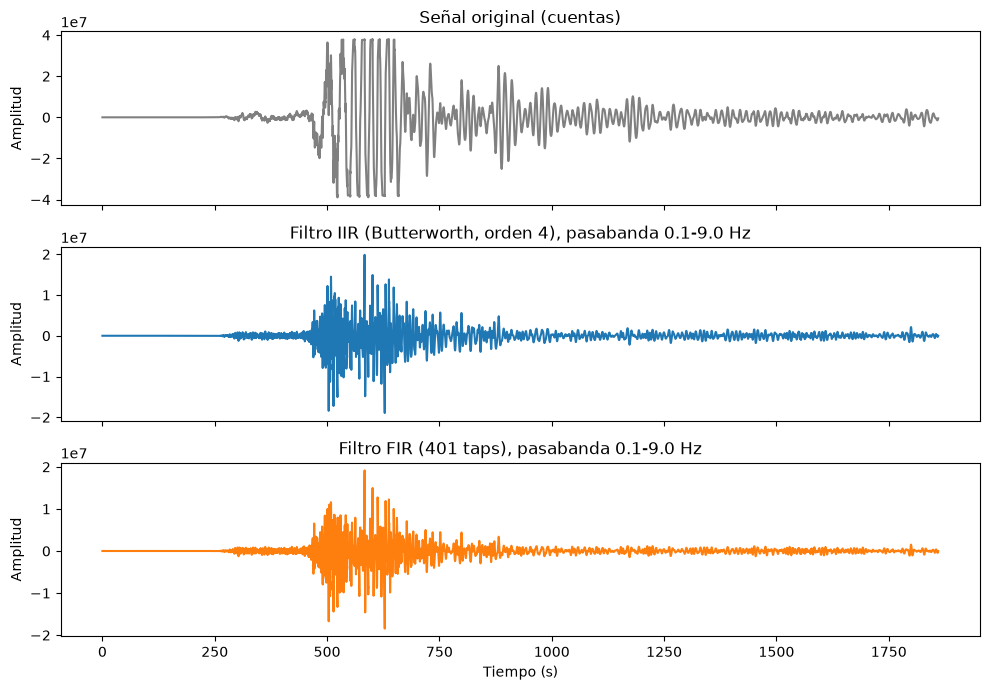

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axs[0].plot(df["tiempo_s"], df["amplitud"], color="gray")
axs[0].set_title("Señal original (cuentas)")

axs[1].plot(df["tiempo_s"], df["amplitud_iir"], color="tab:blue")
axs[1].set_title(f"Filtro IIR (Butterworth, orden {order}), pasabanda {lowcut}-{highcut} Hz")

axs[2].plot(df["tiempo_s"], df["amplitud_fir"], color="tab:orange")
axs[2].set_title(f"Filtro FIR ({numtaps} taps), pasabanda {lowcut}-{highcut} Hz")

axs[2].set_xlabel("Tiempo (s)")
for ax in axs:
    ax.set_ylabel("Amplitud")

plt.tight_layout()
plt.show()


**Podemos observar:**

- Cómo el pasabanda, en ambos metodos, elimina la deriva/tendencia de muy baja frecuencia y el ruido de alta frecuencia que se ven en la señal original.
- La forma de la señal filtrada con IIR y con FIR es parecida, el pasabanda es el mismo pero podemos destacar que FIR se ve "más suave".
